In [2]:
import numpy as np
import pandas as pd
import os

import warnings
warnings.filterwarnings('ignore')
if not os.path.exists("A_merged.csv"):
    A = pd.read_csv("A.csv")
    A_targets = pd.read_csv("A_targets.csv")

    A_merged = pd.merge(A, A_targets, on="Student_ID")
    A_merged.to_csv("A_merged.csv", index=False)

    print("Complete")
else:
    print("Udah ada")

Udah ada


In [3]:
df = pd.read_csv("A_merged.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   object 
 2   branch                       5000 non-null   object 
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  aptitude_skill_rat

In [4]:
df.describe()

,Student_ID,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,internships_completed,coding_skill_rating,communication_skill_rating,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,salary_lpa
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,8.283798,74.537400,74.543060,0.343600,4.041120,72.041560,5.529400,2.132600,3.728600,3.025400,4.116400,3.704200,2.836000,6.955000,6.020200,13.897180
std,1443.520003,1.008391,10.266752,10.244481,0.612547,1.967754,7.720029,2.053772,1.143713,1.278464,1.412358,0.716208,1.603252,1.781724,1.147881,2.851213,6.247481
min,1.000000,5.000000,50.000000,50.000000,0.000000,0.000000,44.700000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000
25%,1250.750000,7.610000,67.400000,67.600000,0.000000,2.700000,66.600000,4.000000,1.000000,3.000000,2.000000,4.000000,3.000000,2.000000,6.200000,4.000000,12.510000
50%,2500.500000,8.320000,74.700000,74.800000,0.000000,4.000000,72.050000,6.000000,2.000000,4.000000,3.000000,4.000000,4.000000,3.000000,7.000000,6.000000,15.760000
75%,3750.250000,9.020000,82.000000,81.700000,1.000000,5.400000,77.200000,7.000000,3.000000,5.000000,4.000000,5.000000,5.000000,4.000000,7.800000,9.000000,18.332500
max,5000.000000,10.000000,100.000000,100.000000,5.000000,10.000000,99.200000,8.000000,4.000000,5.000000,5.000000,5.000000,6.000000,9.000000,9.000000,10.000000,20.000000


In [5]:
df.isna().sum()/len(df)

Student_ID                     0.0000
gender                         0.0000
branch                         0.0000
cgpa                           0.0000
tenth_percentage               0.0000
twelfth_percentage             0.0000
backlogs                       0.0000
study_hours_per_day            0.0000
attendance_percentage          0.0000
projects_completed             0.0000
internships_completed          0.0000
coding_skill_rating            0.0000
communication_skill_rating     0.0000
aptitude_skill_rating          0.0000
hackathons_participated        0.0000
certifications_count           0.0000
sleep_hours                    0.0000
stress_level                   0.0000
part_time_job                  0.0000
family_income_level            0.0000
city_tier                      0.0000
internet_access                0.0000
extracurricular_involvement    0.2012
placement_status               0.0000
salary_lpa                     0.0000
dtype: float64

In [6]:
for col in df.columns:
    unique_vals = df[col].nunique(dropna=False)
    if unique_vals <= 10:
        print(f"--- {col} ({unique_vals} unique values) ---")
        print(df[col].value_counts(dropna=False))
        print("\n")

--- gender (2 unique values) ---
gender
Male      2999
Female    2001
Name: count, dtype: int64


--- branch (5 unique values) ---
branch
CSE    1522
ECE    1336
IT      963
ME      725
CE      454
Name: count, dtype: int64


--- backlogs (6 unique values) ---
backlogs
0    3603
1    1123
2     232
3      38
4       3
5       1
Name: count, dtype: int64


--- projects_completed (9 unique values) ---
projects_completed
8    1061
7     952
6     775
5     641
4     606
3     496
2     296
1     136
0      37
Name: count, dtype: int64


--- internships_completed (5 unique values) ---
internships_completed
2    1586
3    1288
1    1055
4     643
0     428
Name: count, dtype: int64


--- coding_skill_rating (5 unique values) ---
coding_skill_rating
5    1986
4     998
3     967
2     771
1     278
Name: count, dtype: int64


--- communication_skill_rating (5 unique values) ---
communication_skill_rating
4    1044
5    1009
3     992
1     980
2     975
Name: count, dtype: int64


--- aptitu

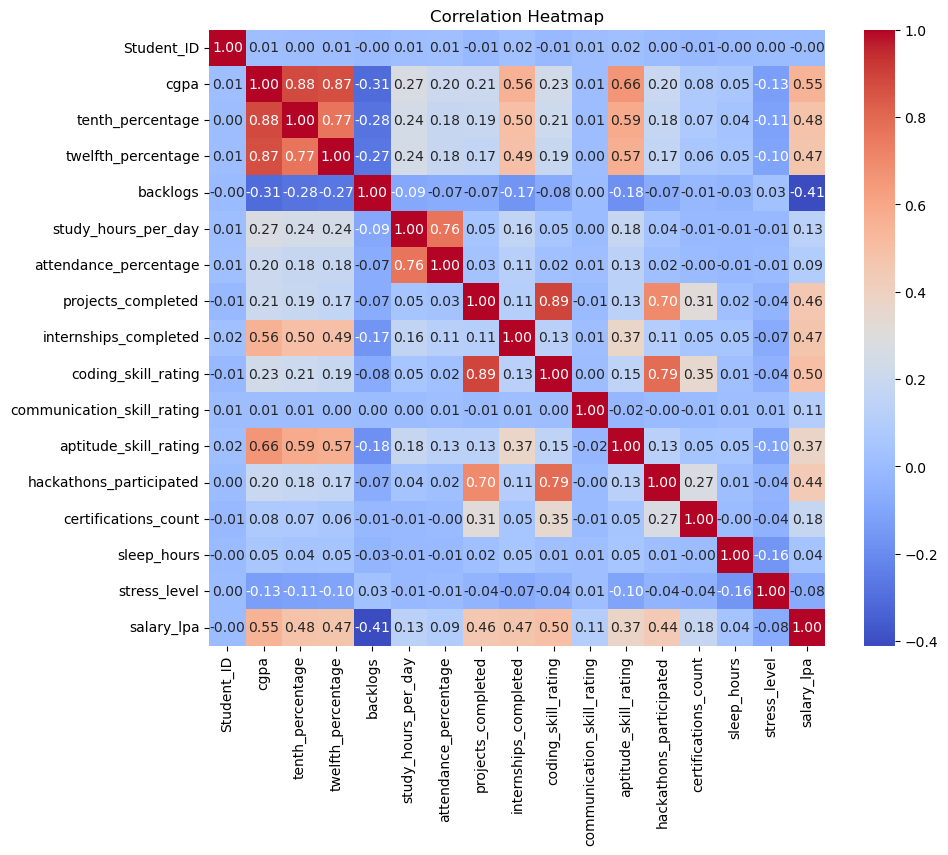

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
#Kita akan kerjakan yang regresi dulu jadi, disini tujuannya cari korelasi kuat ke salary_Ipa

df_num = df.select_dtypes(include=['number'])

corr = df_num.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)

plt.title("Correlation Heatmap")
plt.show()

Feature Engineering (Regresi)

In [8]:
df['Marketability'] = ((df['cgpa'] * 0.4)+(df['coding_skill_rating'] *0.4) + (df['internships_completed'] * 0.3) 
                       + (df['projects_completed'] * 0.2)) #Untuk lihat value porto (softskill = cgpa, hardskill = coding, intern, project)

df['External'] = (df['hackathons_participated'] * 0.8) + (df['certifications_count'] * 0.2) #Untuk lihat seberapa aktif diluar kampus

df['Potential'] = df['aptitude_skill_rating'] / (df['backlogs']+1) #Mengukur kecerdasan dengan korelasi terbalik antara kemampuan logika dengan matkul tidak lulus

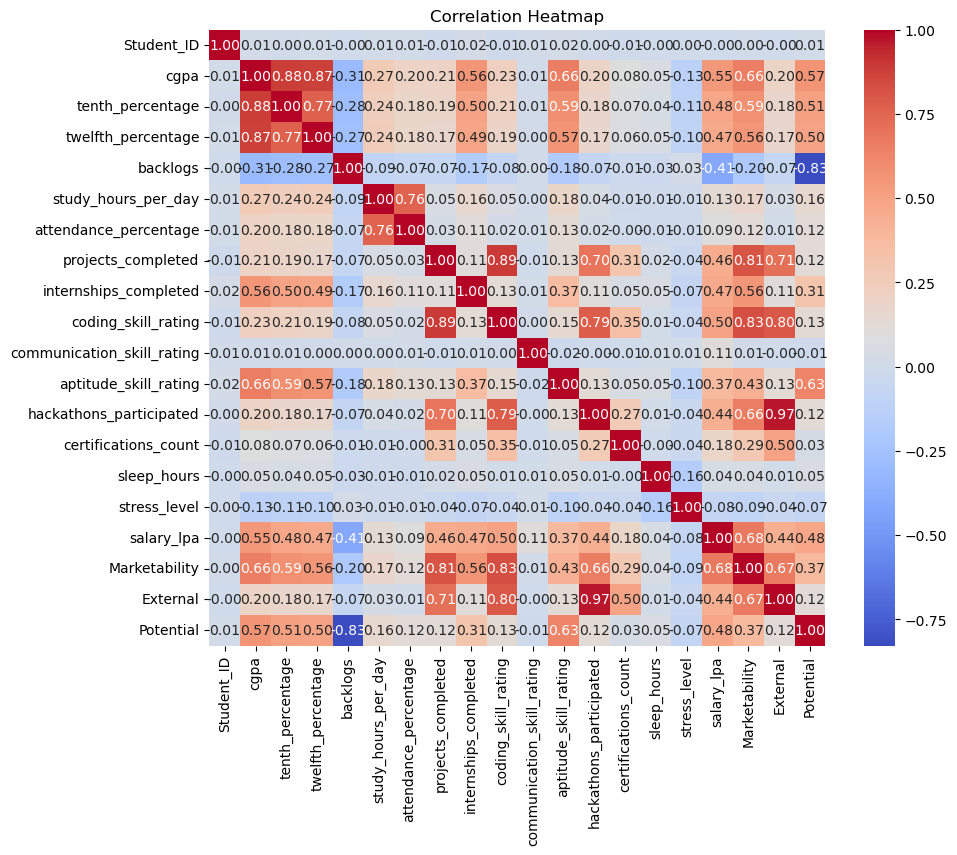

In [9]:
df_num = df.select_dtypes(include=['number'])

corr = df_num.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)

plt.title("Correlation Heatmap")
plt.show()

In [10]:
df_classification = df.copy()
df_regression = df[df['placement_status'] == 'Placed'].copy()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   5000 non-null   int64  
 1   gender                       5000 non-null   object 
 2   branch                       5000 non-null   object 
 3   cgpa                         5000 non-null   float64
 4   tenth_percentage             5000 non-null   float64
 5   twelfth_percentage           5000 non-null   float64
 6   backlogs                     5000 non-null   int64  
 7   study_hours_per_day          5000 non-null   float64
 8   attendance_percentage        5000 non-null   float64
 9   projects_completed           5000 non-null   int64  
 10  internships_completed        5000 non-null   int64  
 11  coding_skill_rating          5000 non-null   int64  
 12  communication_skill_rating   5000 non-null   int64  
 13  aptitude_skill_rat

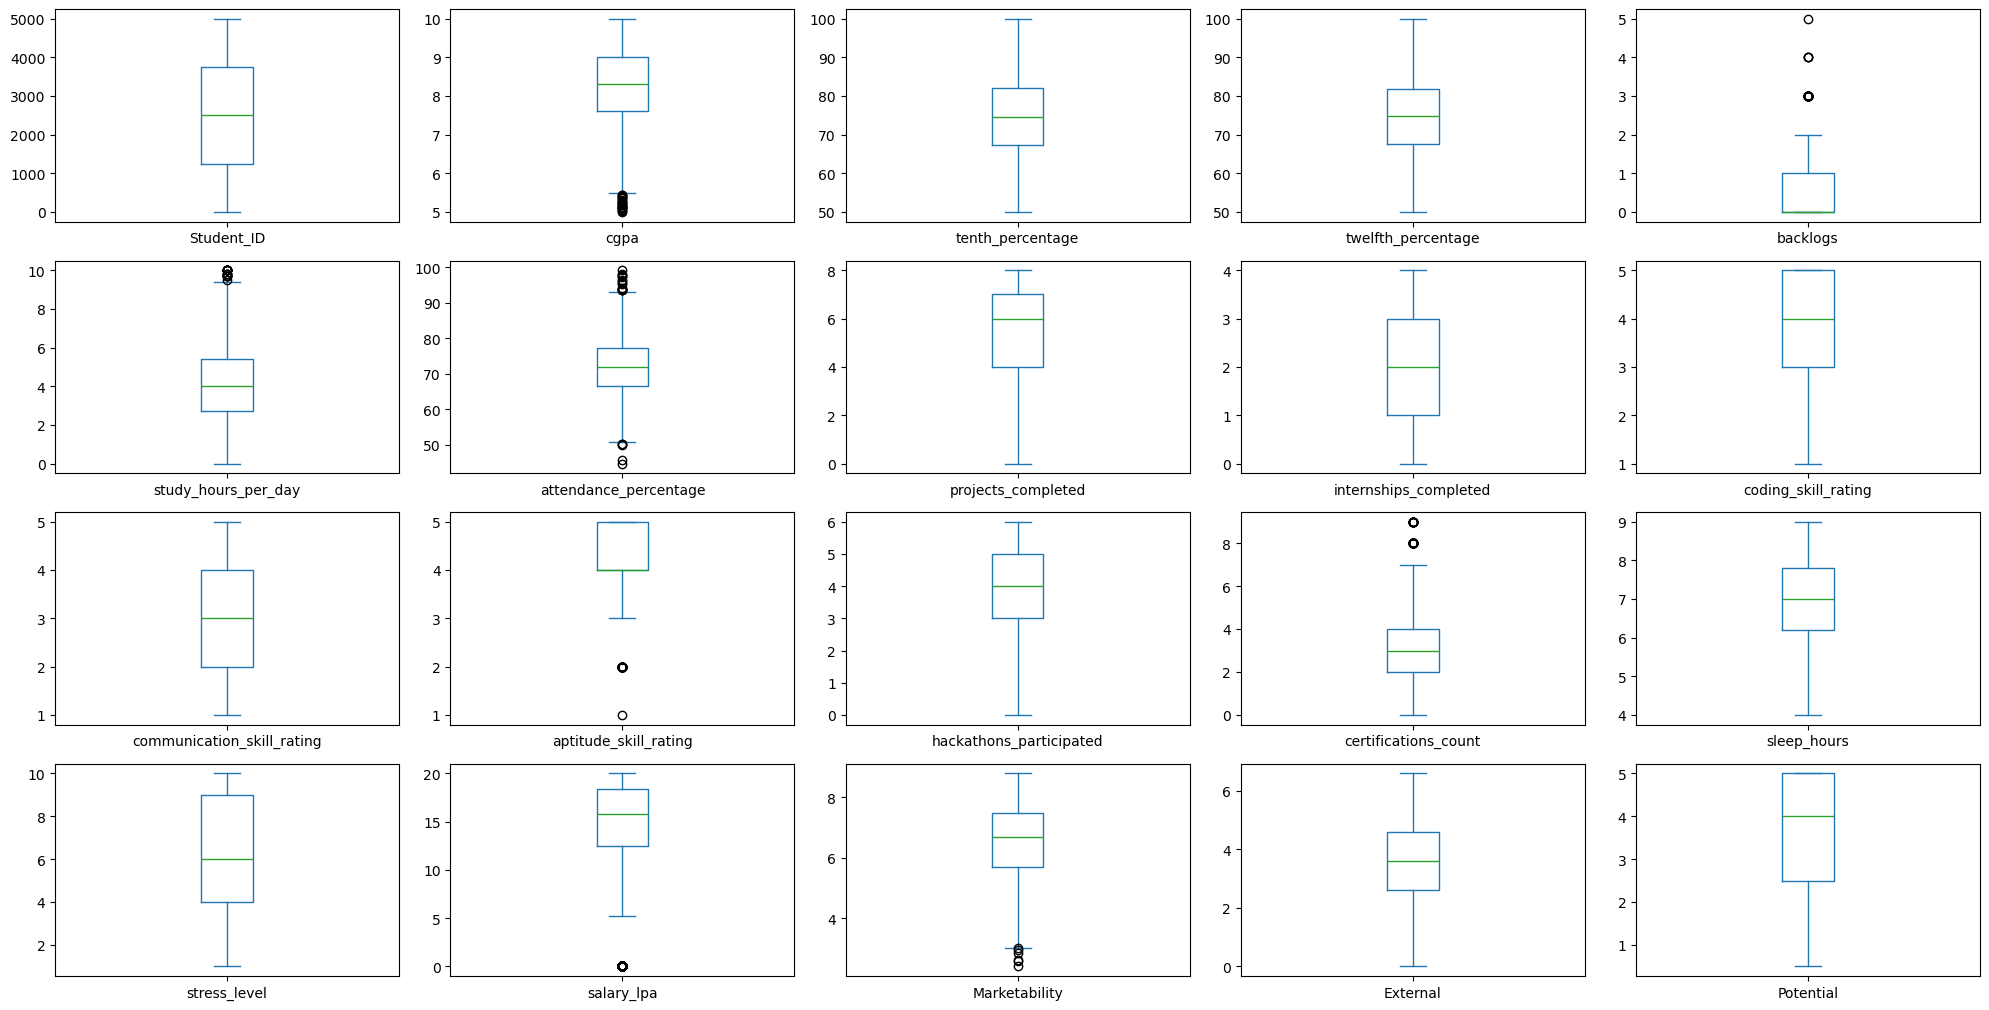

In [12]:
df.select_dtypes(include=['number']).plot(
    kind='box', 
    subplots=True, 
    layout=(6, 5),
    figsize=(20, 15)
)

plt.tight_layout()
plt.show()

EDA

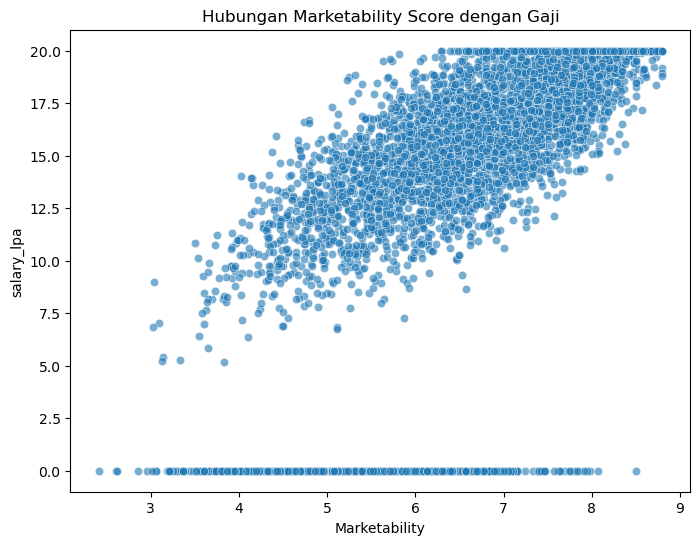

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Marketability', y='salary_lpa', data=df, alpha=0.6)
plt.title('Hubungan Marketability Score dengan Gaji')
plt.show()

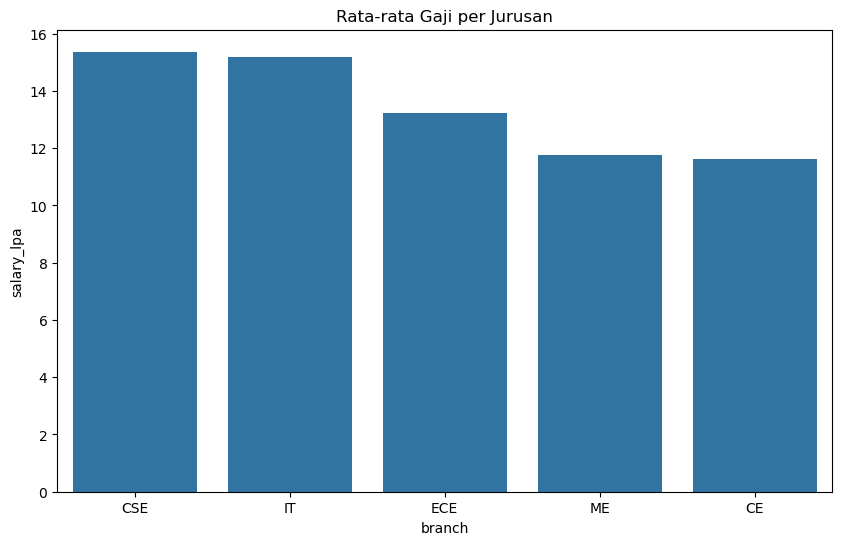

In [14]:
avg_salary = df.groupby('branch')['salary_lpa'].mean().reset_index()

#sorting
avg_salary = avg_salary.sort_values(by='salary_lpa', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='branch', y='salary_lpa', data=avg_salary)

plt.title('Rata-rata Gaji per Jurusan')
plt.show()

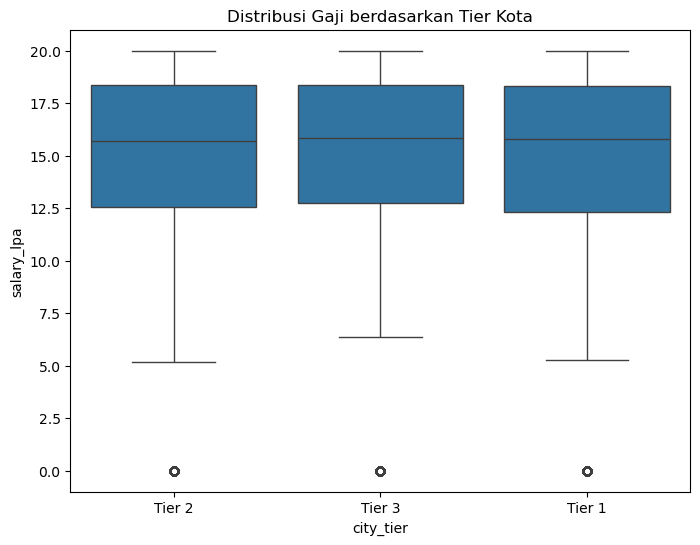

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='city_tier', y='salary_lpa', data=df)
plt.title('Distribusi Gaji berdasarkan Tier Kota')
plt.show()

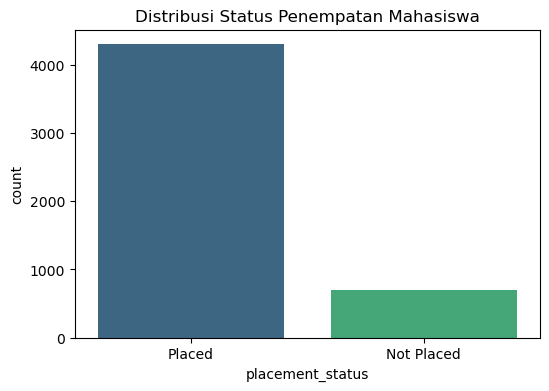

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(x='placement_status', data=df, palette='viridis')
plt.title('Distribusi Status Penempatan Mahasiswa')
plt.show()

Regresi

In [17]:
x_reg = df_regression.drop(['salary_lpa', 'Student_ID', 'placement_status'], axis = 1)
y_reg = df_regression['salary_lpa']

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x_reg, y_reg, test_size = 0.2, random_state = 42)


In [18]:
print(x_train_reg.shape[0])
print(x_test_reg.shape[0])

3442
861


In [19]:
x_train_reg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3442 entries, 4753 to 1001
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       3442 non-null   object 
 1   branch                       3442 non-null   object 
 2   cgpa                         3442 non-null   float64
 3   tenth_percentage             3442 non-null   float64
 4   twelfth_percentage           3442 non-null   float64
 5   backlogs                     3442 non-null   int64  
 6   study_hours_per_day          3442 non-null   float64
 7   attendance_percentage        3442 non-null   float64
 8   projects_completed           3442 non-null   int64  
 9   internships_completed        3442 non-null   int64  
 10  coding_skill_rating          3442 non-null   int64  
 11  communication_skill_rating   3442 non-null   int64  
 12  aptitude_skill_rating        3442 non-null   int64  
 13  hackathons_participa

In [20]:
for col in df.select_dtypes(include=['object']).columns:
    print(f"--- Sebaran Data Kolom: {col} ---")
    print(df[col].value_counts())
    print("\n")

--- Sebaran Data Kolom: gender ---
gender
Male      2999
Female    2001
Name: count, dtype: int64


--- Sebaran Data Kolom: branch ---
branch
CSE    1522
ECE    1336
IT      963
ME      725
CE      454
Name: count, dtype: int64


--- Sebaran Data Kolom: part_time_job ---
part_time_job
No     4007
Yes     993
Name: count, dtype: int64


--- Sebaran Data Kolom: family_income_level ---
family_income_level
Medium    2466
Low       1503
High      1031
Name: count, dtype: int64


--- Sebaran Data Kolom: city_tier ---
city_tier
Tier 2    2023
Tier 3    1547
Tier 1    1430
Name: count, dtype: int64


--- Sebaran Data Kolom: internet_access ---
internet_access
Yes    4461
No      539
Name: count, dtype: int64


--- Sebaran Data Kolom: extracurricular_involvement ---
extracurricular_involvement
Medium    1501
Low       1485
High      1008
Name: count, dtype: int64


--- Sebaran Data Kolom: placement_status ---
placement_status
Placed        4303
Not Placed     697
Name: count, dtype: int64




In [21]:
num_cols = [
    'cgpa', 'tenth_percentage', 'twelfth_percentage', 'backlogs', 
    'study_hours_per_day', 'attendance_percentage', 'projects_completed', 
    'internships_completed', 'coding_skill_rating', 'communication_skill_rating', 
    'aptitude_skill_rating', 'hackathons_participated', 'certifications_count', 
    'sleep_hours', 'stress_level', 'Marketability', 'External', 'Potential'
]

ohe_cols = [
    'gender', 'branch', 
]

yesno_ord= [
    'part_time_job', 'internet_access'
]

lowmedhigh_ord =[
    'family_income_level', 'extracurricular_involvement'
]

tier_ord = [
    'city_tier'
]


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

ohe_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

yesno_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encode', OrdinalEncoder(categories=[['No', 'Yes'], ['No', 'Yes']]))
])

lowmedhigh_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encode', OrdinalEncoder(categories=[
        ['Low', 'Medium', 'High'],
        ['Low', 'Medium', 'High']
    ]))
])

tier_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encode', OrdinalEncoder(categories=[['Tier 1', 'Tier 2', 'Tier 3']]))
])

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('ohe', ohe_transformer, ohe_cols),
        ('yesno', yesno_transformer, yesno_ord),
        ('lowmedhigh', lowmedhigh_transformer, lowmedhigh_ord),
        ('tier', tier_transformer, tier_ord)
    ]
)

Regression Model 1 Random Forest Regression

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf_model = RandomForestRegressor(random_state=42)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', rf_model)
])

In [25]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'regressor__n_estimators': [200],
    'regressor__max_depth': [20],
    'regressor__min_samples_split': [5],
    'regressor__min_samples_leaf': [1],
    'regressor__max_features': ['sqrt'],
    'regressor__bootstrap': [True]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    error_score='raise'
)

rf_grid.fit(x_train_reg, y_train_reg)

rf_best_model   = rf_grid.best_estimator_
rf_best_params  = rf_grid.best_params_
rf_best_mae     = -rf_grid.best_score_

Fitting 5 folds for each of 1 candidates, totalling 5 fits


In [26]:
y_pred_rf = rf_best_model.predict(x_test_reg)

rf_mae_test = mean_absolute_error(y_test_reg, y_pred_rf)
rf_r2_test  = r2_score(y_test_reg, y_pred_rf)

print(f"MAE : {rf_mae_test:.4f}")
print(f"R2  : {rf_r2_test:.4f}")

MAE : 1.1726
R2  : 0.7512


Regression Model 2 Gradient Boosting Regression

In [27]:
from sklearn.ensemble import GradientBoostingRegressor

gbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

gbm_param_grid = {
    'regressor__n_estimators': [300],
    'regressor__learning_rate': [0.05],
    'regressor__max_depth': [3],
    'regressor__min_samples_split': [4],
    'regressor__min_samples_leaf': [2],
    'regressor__subsample': [1.0],
    'regressor__max_features': ['sqrt']
}

gbm_grid = GridSearchCV(
    gbm_pipeline,
    gbm_param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    error_score='raise'
)

gbm_grid.fit(x_train_reg, y_train_reg)

gbm_best_model   = gbm_grid.best_estimator_
gbm_best_params  = gbm_grid.best_params_
gbm_best_mae     = -gbm_grid.best_score_

Fitting 5 folds for each of 1 candidates, totalling 5 fits


In [28]:
y_pred_gbm = gbm_best_model.predict(x_test_reg)

gbm_mae_test = mean_absolute_error(y_test_reg, y_pred_gbm)
gbm_r2_test  = r2_score(y_test_reg, y_pred_gbm)

print(f"MAE : {gbm_mae_test:.4f}")
print(f"R2  : {gbm_r2_test:.4f}")

MAE : 1.0972
R2  : 0.7801


In [29]:
gbm_best_params

{'regressor__learning_rate': 0.05,
 'regressor__max_depth': 3,
 'regressor__max_features': 'sqrt',
 'regressor__min_samples_leaf': 2,
 'regressor__min_samples_split': 4,
 'regressor__n_estimators': 300,
 'regressor__subsample': 1.0}

In [30]:
x_reg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4303 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       4303 non-null   object 
 1   branch                       4303 non-null   object 
 2   cgpa                         4303 non-null   float64
 3   tenth_percentage             4303 non-null   float64
 4   twelfth_percentage           4303 non-null   float64
 5   backlogs                     4303 non-null   int64  
 6   study_hours_per_day          4303 non-null   float64
 7   attendance_percentage        4303 non-null   float64
 8   projects_completed           4303 non-null   int64  
 9   internships_completed        4303 non-null   int64  
 10  coding_skill_rating          4303 non-null   int64  
 11  communication_skill_rating   4303 non-null   int64  
 12  aptitude_skill_rating        4303 non-null   int64  
 13  hackathons_participated

Regression Model 3 XGBoost Regression

In [31]:
from xgboost import XGBRegressor

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ))
])

xgb_param_grid = {
    'regressor__n_estimators': [500],
    'regressor__learning_rate': [0.03],
    'regressor__max_depth': [3],
    'regressor__min_child_weight': [1],
    'regressor__subsample': [0.7],
    'regressor__colsample_bytree': [0.7],
    'regressor__gamma': [0],
    'regressor__reg_alpha': [0.05],
    'regressor__reg_lambda': [1]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    error_score='raise'
)

xgb_grid.fit(x_train_reg, y_train_reg)

xgb_best_model  = xgb_grid.best_estimator_
xgb_best_params = xgb_grid.best_params_
xgb_best_mae    = -xgb_grid.best_score_

Fitting 5 folds for each of 1 candidates, totalling 5 fits


In [32]:
y_pred_xgb = xgb_best_model.predict(x_test_reg)

xgb_mae_test = mean_absolute_error(y_test_reg, y_pred_xgb)
xgb_r2_test  = r2_score(y_test_reg, y_pred_xgb)

print(f"MAE : {xgb_mae_test:.4f}")
print(f"R2  : {xgb_r2_test:.4f}")

MAE : 1.1014
R2  : 0.7772


Best Model Regression

In [33]:
print("Random Forest")
print(f"MAE : {rf_mae_test:.4f}")
print(f"R2  : {rf_r2_test:.4f}")
print()

print("Gradient Boosting")
print(f"MAE : {gbm_mae_test:.4f}")
print(f"R2  : {gbm_r2_test:.4f}")
print()

print("XGBoost")
print(f"MAE : {xgb_mae_test:.4f}")
print(f"R2  : {xgb_r2_test:.4f}")

best_model_regression = gbm_best_model

Random Forest
MAE : 1.1726
R2  : 0.7512

Gradient Boosting
MAE : 1.0972
R2  : 0.7801

XGBoost
MAE : 1.1014
R2  : 0.7772


Klasifikasi

In [34]:
x_clas = df_classification.drop(['salary_lpa', 'Student_ID', 'placement_status'], axis = 1)
y_clas = df_classification['placement_status']

x_train_clas, x_test_clas, y_train_clas, y_test_clas = train_test_split(x_clas, y_clas, test_size = 0.2, random_state = 42, stratify= y_clas)

In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf_model = RandomForestRegressor(random_state=42)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', rf_model)
])

In [36]:
Order = {"Not Placed": 0,
         "Placed" : 1
         }

y_train_clas = y_train_clas.map(Order)
y_test_clas = y_test_clas.map(Order)

Classification Model 1 Random Forest Classifier

In [37]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline

rf_clas_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_clas_param_grid = {
    'classifier__n_estimators': [300],
    'classifier__max_depth': [20],
    'classifier__min_samples_split': [2],
    'classifier__min_samples_leaf': [1],
    'classifier__max_features': ['log2']
}

rf_clas_grid = GridSearchCV(
    rf_clas_pipeline,
    rf_clas_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    error_score='raise'
)

rf_clas_grid.fit(x_train_clas, y_train_clas)

rf_clas_best_model  = rf_clas_grid.best_estimator_
rf_clas_best_params = rf_clas_grid.best_params_
rf_clas_best_f1     = rf_clas_grid.best_score_

Fitting 5 folds for each of 1 candidates, totalling 5 fits


In [49]:
from sklearn.metrics import f1_score
y_proba_rf = rf_clas_best_model.predict_proba(x_test_clas)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_macros = []

for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    score = f1_score(y_test_clas, y_pred_t, average='macro')
    f1_macros.append(score)

best_idx = np.argmax(f1_macros)
best_t = thresholds[best_idx]
best_score = f1_macros[best_idx]

print(f"Best threshold: {best_t:.2f} -> F1-macro: {best_score:.4f}")

Best threshold: 0.32 -> F1-macro: 0.7620


In [39]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_best_rf = (y_proba_rf >= best_t).astype(int)

print("RANDOM FOREST (TUNED + THRESHOLD)")
print(classification_report(y_test_clas, y_pred_best_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test_clas, y_pred_best_rf))

RANDOM FOREST (TUNED + THRESHOLD)
              precision    recall  f1-score   support

           0       0.53      0.68      0.60       139
           1       0.95      0.90      0.92       861

    accuracy                           0.87      1000
   macro avg       0.74      0.79      0.76      1000
weighted avg       0.89      0.87      0.88      1000

Confusion Matrix:
[[ 95  44]
 [ 83 778]]


Classification Model 2 Gradient Boosting Classifier

In [40]:
from sklearn.ensemble import HistGradientBoostingClassifier
from imblearn.combine import SMOTEENN
gbm_clas_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTEENN(random_state=42)),
    ('classifier', HistGradientBoostingClassifier(random_state=42))
])

gbm_clas_param_grid = {
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [None, 10, 15],
    'classifier__max_iter': [100, 200],
    'classifier__min_samples_leaf': [20, 50],
    'classifier__l2_regularization': [0, 0.1]
}

gbm_clas_grid = GridSearchCV(
    gbm_clas_pipeline,
    gbm_clas_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

gbm_clas_grid.fit(x_train_clas, y_train_clas)

gbm_clas_best_model  = gbm_clas_grid.best_estimator_
gbm_clas_best_params = gbm_clas_grid.best_params_
gbm_clas_best_f1     = gbm_clas_grid.best_score_

Fitting 5 folds for each of 48 candidates, totalling 240 fits


In [51]:
from sklearn.metrics import f1_score
y_proba_gbm = gbm_clas_best_model.predict_proba(x_test_clas)[:, 1]

f1_macros = []
thresholds = np.arange(0.05, 0.95, 0.005)
for t in thresholds:
    y_pred_t = (y_proba_gbm >= t).astype(int)
    score = f1_score(y_test_clas, y_pred_t, average='macro')
    f1_macros.append(score)

best_idx = np.argmax(f1_macros)
best_t = thresholds[best_idx]
best_score = f1_macros[best_idx]

print(f"Best threshold: {best_t:.2f} -> F1-macro: {best_score:.4f}")

Best threshold: 0.18 -> F1-macro: 0.7621


In [42]:
y_pred_best_gbm = (y_proba_gbm >= best_t).astype(int)

print("Gradient Boosting (TUNED + THRESHOLD)")
print(classification_report(y_test_clas, y_pred_best_gbm))

print("Confusion Matrix:")
print(confusion_matrix(y_test_clas, y_pred_best_gbm))

Gradient Boosting (TUNED + THRESHOLD)
              precision    recall  f1-score   support

           0       0.54      0.66      0.60       139
           1       0.94      0.91      0.93       861

    accuracy                           0.88      1000
   macro avg       0.74      0.79      0.76      1000
weighted avg       0.89      0.88      0.88      1000

Confusion Matrix:
[[ 92  47]
 [ 77 784]]


Classification Model 3 XGBoost Classifier

In [43]:
from xgboost import XGBClassifier
xgb_clas_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        eval_metric='aucpr',
        random_state=42,
        use_label_encoder=False
    ))
])

xgb_clas_param_grid = {
    'classifier__n_estimators': [300],
    'classifier__max_depth': [5],
    'classifier__learning_rate': [0.1],
    'classifier__subsample': [0.8],
    'classifier__colsample_bytree': [0.8],
    'classifier__min_child_weight': [1, 3],
    'classifier__gamma': [0],
    'classifier__reg_alpha': [0.1],
    'classifier__reg_lambda': [1]
}

xgb_clas_grid = GridSearchCV(
    xgb_clas_pipeline,
    xgb_clas_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

xgb_clas_grid.fit(x_train_clas, y_train_clas)

xgb_clas_best_model  = xgb_clas_grid.best_estimator_
xgb_clas_best_params = xgb_clas_grid.best_params_
xgb_clas_best_f1  = xgb_clas_grid.best_score_

Fitting 5 folds for each of 2 candidates, totalling 10 fits


In [44]:
xgb_clas_best_params

{'classifier__colsample_bytree': 0.8,
 'classifier__gamma': 0,
 'classifier__learning_rate': 0.1,
 'classifier__max_depth': 5,
 'classifier__min_child_weight': 3,
 'classifier__n_estimators': 300,
 'classifier__reg_alpha': 0.1,
 'classifier__reg_lambda': 1,
 'classifier__subsample': 0.8}

In [50]:
y_proba_xgb = xgb_clas_best_model.predict_proba(x_test_clas)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.005)
f1_macros = []

for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    score = f1_score(y_test_clas, y_pred_t, average='macro')
    f1_macros.append(score)

best_idx = np.argmax(f1_macros)
best_t = thresholds[best_idx]
best_score = f1_macros[best_idx]

print(f"Best threshold: {best_t:.2f} -> F1-macro: {best_score:.4f}")

Best threshold: 0.79 -> F1-macro: 0.7668


In [46]:
y_pred_xgb = (y_proba_xgb >= best_t).astype(int)

print("XGBoost (TUNED + THRESHOLD)")
print(classification_report(y_test_clas, y_pred_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test_clas, y_pred_xgb))

XGBoost (TUNED + THRESHOLD)
              precision    recall  f1-score   support

           0       0.54      0.71      0.61       139
           1       0.95      0.90      0.92       861

    accuracy                           0.87      1000
   macro avg       0.74      0.80      0.77      1000
weighted avg       0.89      0.87      0.88      1000

Confusion Matrix:
[[ 98  41]
 [ 85 776]]


In [47]:
print("RANDOM FOREST (TUNED + THRESHOLD)")
print(classification_report(y_test_clas, y_pred_best_rf))

print("Gradient Boosting (TUNED + THRESHOLD)")
print(classification_report(y_test_clas, y_pred_best_gbm))

print("XGBoost (TUNED + THRESHOLD)")
print(classification_report(y_test_clas, y_pred_xgb))

RANDOM FOREST (TUNED + THRESHOLD)
              precision    recall  f1-score   support

           0       0.53      0.68      0.60       139
           1       0.95      0.90      0.92       861

    accuracy                           0.87      1000
   macro avg       0.74      0.79      0.76      1000
weighted avg       0.89      0.87      0.88      1000

Gradient Boosting (TUNED + THRESHOLD)
              precision    recall  f1-score   support

           0       0.54      0.66      0.60       139
           1       0.94      0.91      0.93       861

    accuracy                           0.88      1000
   macro avg       0.74      0.79      0.76      1000
weighted avg       0.89      0.88      0.88      1000

XGBoost (TUNED + THRESHOLD)
              precision    recall  f1-score   support

           0       0.54      0.71      0.61       139
           1       0.95      0.90      0.92       861

    accuracy                           0.87      1000
   macro avg       0.74     

In [48]:
best_model_classification = xgb_clas_best_model